# Lecture 6d — Risk Parity, Volatility Targeting and Reflexivity

**25882 AI-powered Investment and Risk Management** · UTS Business School

---

The previous three notebooks estimated a risk model, summarised it, and checked it. This
one turns the measurement into a **decision**: the risk decomposition itself becomes the
allocation rule.

Then it asks the question the textbooks skip. A risk model is not a passive observer — it
issues instructions. When many investors run similar models, those instructions arrive at
the same time. The last section builds a market where that happens and watches what it does
to the risk the model was measuring.

**Boundary note.** Hierarchical Risk Parity is the fourth member of this family, and
Lecture 3 covers it (`Lec03c`). We reference it here rather than repeating it.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import riskfolio as rp
import airm6 as a6

ASSETS = ["AAPL", "JPM", "XOM", "JNJ", "PG", "NEM"]

prices = a6.get_prices(ASSETS)
Y = a6.log_returns(prices)
Sigma = Y.cov().to_numpy() * 252
vol = np.sqrt(np.diag(Sigma))

corr = Y.corr().to_numpy()[np.triu_indices(len(ASSETS), 1)]
print(pd.Series(vol * 100, index=ASSETS, name="annualised vol (%)").round(1).to_string())
print(f"\npairwise correlations: min {corr.min():.2f}  max {corr.max():.2f}  "
      f"mean {corr.mean():.2f}")

AAPL    23.2
JPM     20.4
XOM     17.5
JNJ     14.3
PG      14.2
NEM     40.0

pairwise correlations: min 0.00  max 0.50  mean 0.27


These six were chosen so that **correlation does real work**. NEM (a gold miner) is by far
the most volatile name and also the least correlated with the rest. Watch what the different
allocation rules do with it.

---
## 1. The Euler decomposition is an identity, not an approximation

Portfolio volatility is homogeneous of degree one in the weights, so Euler's theorem gives
an *exact* additive split into per-asset contributions. That exactness is what makes it
usable as a budget: the parts genuinely sum to the whole.

<details>
<summary><b>The decomposition (click to expand)</b></summary>

$$\sigma_p(w) = \sqrt{w^\top \Sigma w}, \qquad
\mathrm{MRC}_i = \frac{\partial \sigma_p}{\partial w_i} = \frac{(\Sigma w)_i}{\sigma_p},
\qquad \mathrm{TRC}_i = w_i \,\mathrm{MRC}_i$$

$$\sum_i \mathrm{TRC}_i = \frac{w^\top \Sigma w}{\sigma_p} = \sigma_p$$

Note what is buried inside $(\Sigma w)_i$: an asset's risk contribution depends on its
**covariance with everything else**, not just on its own volatility.

</details>

In [2]:
w_test = np.array([0.30, 0.20, 0.15, 0.15, 0.10, 0.10])

sigma_p = float(np.sqrt(w_test @ Sigma @ w_test))
trc = w_test * (Sigma @ w_test) / sigma_p

print(f"portfolio volatility      {sigma_p * 100:.4f}%")
print(f"sum of contributions      {trc.sum() * 100:.4f}%")
print(f"difference                {abs(sigma_p - trc.sum()):.2e}  <- machine precision")

portfolio volatility      13.2990%
sum of contributions      13.2990%
difference                0.00e+00  <- machine precision


---
## 2. Three things people call "risk parity"

The term is used for at least three different rules, and they do not agree.

| Rule | Definition | Uses correlation? |
|---|---|---|
| **Equal weight** | $w_i = 1/N$ | no |
| **Inverse volatility** | $w_i \propto 1/\sigma_i$ | **no** |
| **Equal risk contribution** | $\mathrm{TRC}_i$ equal for all $i$ | yes |

Inverse volatility is very widely described as "risk parity". It is not.

In [3]:
n = len(ASSETS)
w_eq = np.repeat(1 / n, n)
w_iv = a6.inverse_vol_weights(Sigma)
w_erc = a6.erc_weights(Sigma)

weights = pd.DataFrame({"Equal weight": w_eq, "Inverse volatility": w_iv,
                        "Equal risk contribution": w_erc}, index=ASSETS)
contribs = pd.DataFrame({c: a6.risk_contributions(weights[c].to_numpy(), Sigma)
                         for c in weights}, index=ASSETS)

spread = (contribs.max() - contribs.min()) * 100
portvol = pd.Series({c: np.sqrt(weights[c] @ Sigma @ weights[c]) * 100 for c in weights})

display(pd.concat({"capital weight (%)": weights * 100,
                   "risk contribution (%)": contribs * 100}, axis=1)
        .style.format("{:.1f}").set_caption("Weights and risk contributions"))

display(pd.DataFrame({"portfolio vol (%)": portvol,
                      "risk contribution spread (pp)": spread})
        .style.format("{:.2f}").set_caption("Summary"))

,portfolio vol (%),risk contribution spread (pp)
Equal weight,12.99,20.91
Inverse volatility,11.92,9.76
Equal risk contribution,12.10,0.00


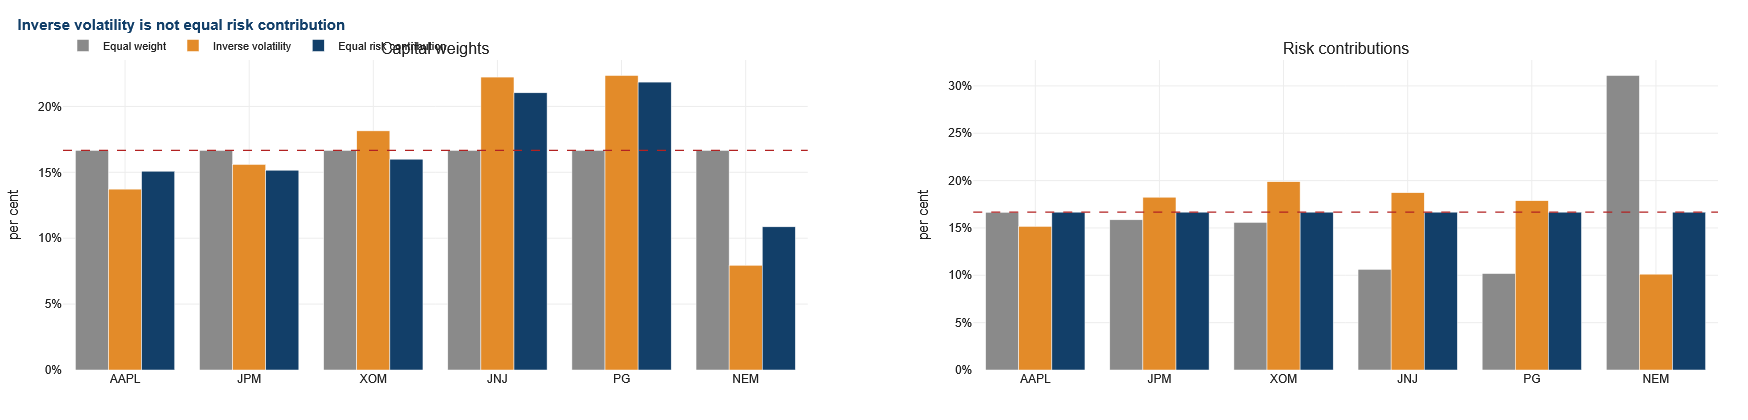

In [4]:
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=("Capital weights", "Risk contributions"))
for j, frame in enumerate([weights, contribs], start=1):
    for name, colour in zip(frame.columns, [a6.GREY, a6.ORANGE, a6.NAVY]):
        fig.add_trace(go.Bar(x=ASSETS, y=frame[name] * 100, name=name,
                             marker_color=colour, showlegend=(j == 1)), row=1, col=j)
    fig.add_hline(y=100 / n, line=dict(color=a6.RED, width=1.4, dash="dash"),
                  row=1, col=j)

a6.style(fig, title="Inverse volatility is not equal risk contribution", height=420)
fig.update_yaxes(title="per cent", ticksuffix="%")
fig.show()

In [5]:
i_nem = ASSETS.index("NEM")
print(f"NEM: annualised volatility {vol[i_nem]*100:.1f}% "
      f"(the highest), average correlation with the others "
      f"{np.delete(Y.corr().to_numpy()[i_nem], i_nem).mean():.2f} (the lowest)\n")
for rule in weights:
    print(f"{rule:<26s} weight {weights[rule].iloc[i_nem]*100:5.1f}%   "
          f"risk contribution {contribs[rule].iloc[i_nem]*100:5.1f}%")

NEM: annualised volatility 40.0% (the highest), average correlation with the others 0.08 (the lowest)

Equal weight               weight  16.7%   risk contribution  31.1%
Inverse volatility         weight   7.9%   risk contribution  10.1%
Equal risk contribution    weight  10.9%   risk contribution  16.7%


**This is the result to dwell on.** Under inverse volatility NEM gets the *smallest*
allocation — it is the most volatile name, so the rule shrinks it hardest — and yet it
still contributes *less* than its equal share of risk, because its low correlation means it
diversifies rather than adds.

To bring NEM to a genuine one-sixth of portfolio risk, ERC has to **increase** its weight.

The general lesson: **inverse volatility systematically under-allocates to diversifiers.**
It treats volatility as if it were risk, when the quantity that matters is the covariance
with everything else you hold.

### When are the two the same?

Exactly when correlations are homogeneous. Let us verify that claim rather than assert it.

In [6]:
def equicorrelated(vols, rho):
    C = np.full((len(vols), len(vols)), rho)
    np.fill_diagonal(C, 1.0)
    return np.outer(vols, vols) * C

print(f"{'rho':>6s}{'max |w_iv - w_erc| (pp)':>28s}")
for rho in [0.0, 0.2, 0.4, 0.6, 0.9]:
    S = equicorrelated(vol, rho)
    diff = np.abs(a6.inverse_vol_weights(S) - a6.erc_weights(S)).max() * 100
    print(f"{rho:>6.1f}{diff:>28.4f}")

print("\nWith the ACTUAL (heterogeneous) correlation matrix:")
print(f"{'':>6s}{np.abs(w_iv - w_erc).max() * 100:>28.4f}")

   rho     max |w_iv - w_erc| (pp)
   0.0                      0.0000
   0.2                      0.0000
   0.4                      0.0000
   0.6                      0.0000
   0.9                      0.0000

With the ACTUAL (heterogeneous) correlation matrix:
                            2.9168


Under equicorrelation the two rules coincide to machine precision, at *any* level of
correlation. The gap in the last row is caused entirely by the **dispersion** of
correlations, not by their average level.

---
## 3. Riskfolio-Lib: solving it properly

`airm6.erc_weights` solves Spinu's convex reformulation directly. Riskfolio-Lib solves the
same problem through a conic solver and generalises it in ways we want. Let us confirm they
agree before relying on either.

> **Note on solvers.** Older versions of this notebook set `port.solvers = ['MOSEK']`.
> MOSEK is commercial and licence-gated, so that code fails for most students. Everything
> below runs on the open-source **CLARABEL** solver that ships with `cvxpy`.

In [7]:
port = rp.Portfolio(returns=Y)
port.assets_stats(method_mu="hist", method_cov="hist")
port.solvers = ["CLARABEL", "SCS"]

w_rf = port.rp_optimization(model="Classic", rm="MV", rf=0, b=None, hist=True)

check = pd.DataFrame({"airm6 (Spinu)": w_erc * 100,
                      "Riskfolio (CLARABEL)": w_rf.to_numpy().ravel() * 100},
                     index=ASSETS)
check["difference (pp)"] = check.iloc[:, 0] - check.iloc[:, 1]
display(check.style.format("{:.4f}").set_caption("Two solvers, one problem"))
print(f"maximum absolute difference: {check['difference (pp)'].abs().max():.5f} "
      "percentage points")

,airm6 (Spinu),Riskfolio (CLARABEL),difference (pp)
AAPL,15.0870,15.0871,-0.0001
JPM,15.1624,15.1624,-0.0000
XOM,15.9992,15.9993,-0.0001
JNJ,21.0365,21.0365,0.0001
PG,21.8489,21.8488,0.0001
NEM,10.8661,10.8659,0.0001


maximum absolute difference: 0.00013 percentage points


### Risk budgeting: equal is just one choice

Replace the equal target $1/n$ with any budget vector $b$ and the same machinery allocates
risk however you like. This is what allocators usually want — not equality, but *control*.

In [8]:
budget = np.array([0.30, 0.20, 0.20, 0.10, 0.10, 0.10])
w_rb = port.rp_optimization(model="Classic", rm="MV", rf=0,
                            b=budget.reshape(-1, 1), hist=True).to_numpy().ravel()

achieved = a6.risk_contributions(w_rb, Sigma)
display(pd.DataFrame({"target risk budget (%)": budget * 100,
                      "achieved (%)": achieved * 100,
                      "capital weight (%)": w_rb * 100}, index=ASSETS)
        .style.format("{:.1f}").set_caption("Risk budgeting hits the target exactly"))

,target risk budget (%),achieved (%),capital weight (%)
AAPL,30.0,30.0,23.6
JPM,20.0,20.0,18.0
XOM,20.0,20.0,19.9
JNJ,10.0,10.0,14.6
PG,10.0,10.0,15.4
NEM,10.0,10.0,8.4


Notice that the capital weights bear no simple relationship to the risk budget. That is the
entire point: **risk budgeting decouples what you allocate from what you are exposed to.**

### The measure you equalise is a modelling choice too

Riskfolio 7.3 supports risk parity across many convex risk measures. Equalising CVaR
contributions gives a *different* portfolio from equalising variance contributions — and
Notebook 06a tells you which of them are coherent.

In [9]:
measures = {"MV": "Variance", "MAD": "Mean absolute deviation",
            "CVaR": "Conditional VaR", "EVaR": "Entropic VaR",
            "CDaR": "Conditional drawdown"}

out = {}
for code, label in measures.items():
    try:
        w = port.rp_optimization(model="Classic", rm=code, rf=0, b=None, hist=True)
        out[label] = w.to_numpy().ravel() * 100
    except Exception as exc:
        print(f"  {label}: unavailable ({type(exc).__name__})")

alt = pd.DataFrame(out, index=ASSETS)
display(alt.style.format("{:.1f}").background_gradient(cmap="Blues", axis=None)
        .set_caption("Risk parity under different risk measures (capital weights, %)"))
print(f"Largest disagreement between measures for any single asset: "
      f"{(alt.max(axis=1) - alt.min(axis=1)).max():.1f} percentage points")

,Variance,Mean absolute deviation,Conditional VaR,Entropic VaR,Conditional drawdown
AAPL,15.1,14.3,15.8,19.4,11.2
JPM,15.2,15.4,14.4,14.6,21.8
XOM,16.0,16.2,15.8,14.1,14.8
JNJ,21.0,21.6,20.9,18.7,25.4
PG,21.8,21.6,22.4,19.9,21.7
NEM,10.9,10.8,10.8,13.2,5.1


Largest disagreement between measures for any single asset: 8.1 percentage points


The drawdown-based version differs most, because it scores a *cumulative path* rather than a
per-period distribution — the same category distinction we met in Notebook 06a.

---
## 4. Volatility targeting

Risk parity balances risk *across assets*. Volatility targeting stabilises risk *through
time*, by scaling the whole portfolio:

$$w_{\text{scaled},t} = w_{\text{base}} \cdot \frac{\sigma_{\text{target}}}{\hat\sigma_t}$$

Everything now rests on $\hat\sigma_t$ — a forecast, from Notebook 06b, entering a decision
rule. If the forecast is slow, the portfolio de-risks *after* the loss rather than before.

In [10]:
TARGET, MAXLEV = 0.10, 2.0

base = a6.portfolio_returns(Y, w_erc)                 # the ERC portfolio
sigma_hat = np.sqrt(a6.ewma_var(base, lam=0.94, warmup=250))
lev = pd.Series(a6.vol_target_leverage(sigma_hat, TARGET, MAXLEV),
                index=base.index).shift(1)            # traded on yesterday's estimate

managed = (lev * base).dropna()
unmanaged = base.loc[managed.index]

stats_tbl = pd.DataFrame({
    "Unmanaged ERC": {
        "ann. return (%)": unmanaged.mean() * 252 * 100,
        "ann. volatility (%)": unmanaged.std() * np.sqrt(252) * 100,
        "Sharpe (rf=0)": unmanaged.mean() / unmanaged.std() * np.sqrt(252),
        "worst day (%)": unmanaged.min() * 100,
        "max drawdown (%)": ((unmanaged.cumsum() - unmanaged.cumsum().cummax()).min()) * 100,
        "annual turnover (x)": 0.0},
    "Volatility targeted": {
        "ann. return (%)": managed.mean() * 252 * 100,
        "ann. volatility (%)": managed.std() * np.sqrt(252) * 100,
        "Sharpe (rf=0)": managed.mean() / managed.std() * np.sqrt(252),
        "worst day (%)": managed.min() * 100,
        "max drawdown (%)": ((managed.cumsum() - managed.cumsum().cummax()).min()) * 100,
        "annual turnover (x)": lev.diff().abs().sum() / (len(lev.dropna()) / 252)},
}).T
display(stats_tbl.style.format("{:.2f}").set_caption(
    "Volatility targeting the ERC portfolio (10% target, leverage capped at 2)"))

,ann. return (%),ann. volatility (%),Sharpe (rf=0),worst day (%),max drawdown (%),annual turnover (x)
Unmanaged ERC,8.63,12.32,0.70,-4.38,-20.98,0.00
Volatility targeted,7.87,10.92,0.72,-4.88,-17.77,8.30


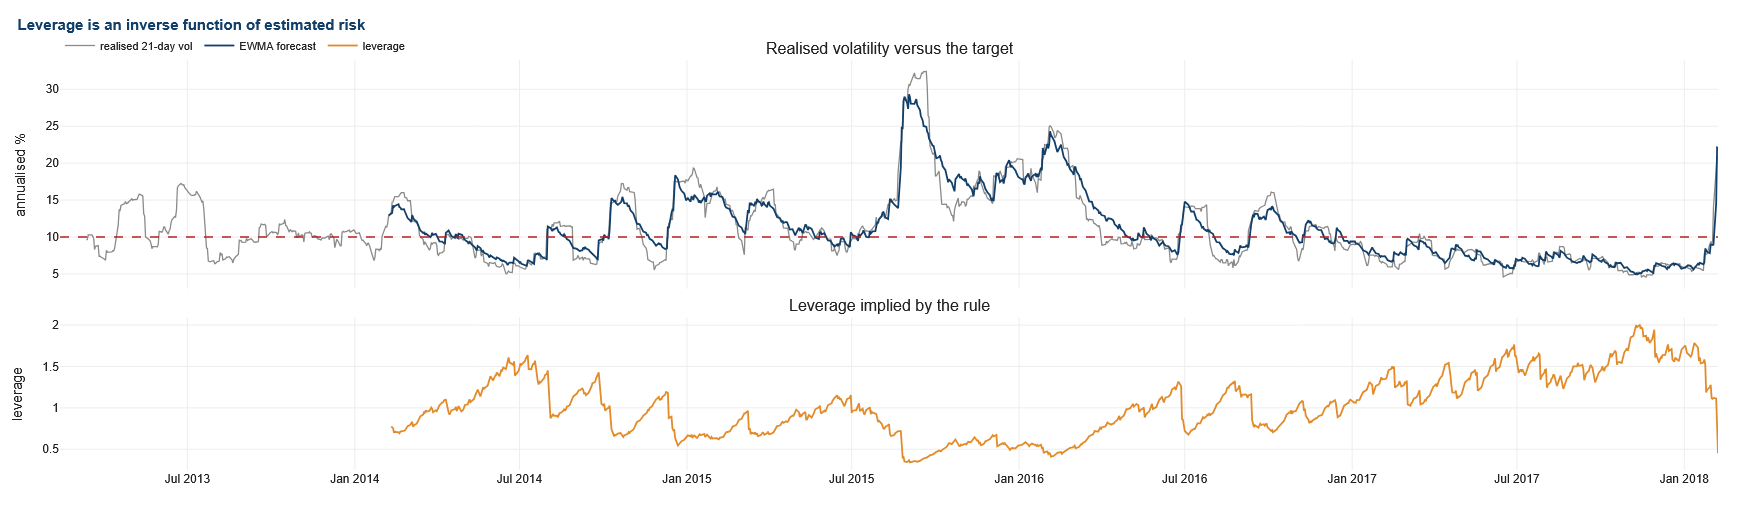

In [11]:
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, row_heights=[0.6, 0.4],
                    vertical_spacing=0.07,
                    subplot_titles=("Realised volatility versus the target",
                                    "Leverage implied by the rule"))
realised = base.rolling(21).std() * np.sqrt(252) * 100
fig.add_trace(go.Scatter(x=realised.index, y=realised, name="realised 21-day vol",
                         line=dict(color=a6.GREY, width=1.3)), row=1, col=1)
fig.add_trace(go.Scatter(x=sigma_hat.index, y=sigma_hat * np.sqrt(252) * 100,
                         name="EWMA forecast", line=dict(color=a6.NAVY, width=1.8)),
              row=1, col=1)
fig.add_hline(y=TARGET * 100, line=dict(color=a6.RED, width=1.4, dash="dash"), row=1, col=1)
fig.add_trace(go.Scatter(x=lev.index, y=lev, name="leverage",
                         line=dict(color=a6.ORANGE, width=1.8)), row=2, col=1)

a6.style(fig, title="Leverage is an inverse function of estimated risk", height=520)
fig.update_yaxes(title="annualised %", row=1, col=1)
fig.update_yaxes(title="leverage", row=2, col=1)
fig.show()

The rule does what it promises: realised volatility is closer to the 10% target than the
unmanaged portfolio's. It also costs turnover, and that turnover is the tax on
responsiveness — a faster volatility estimate gives a tighter target and a larger trading
bill.

**Does it improve returns?** That is a live argument in the literature, and you should not
present it as settled:

- [Moreira and Muir (2017)](https://doi.org/10.1111/jofi.12513) find significant alphas from
  scaling exposure down when volatility is high.
- [Cederburg, O'Doherty, Wang and Yan (2020)](https://doi.org/10.1016/j.jfineco.2020.04.015)
  show that across 103 strategies the implied trades are not implementable in real time, and
  reasonable out-of-sample versions earn *lower* Sharpe ratios.
- [Barroso and Detzel (2021)](https://doi.org/10.1016/j.jfineco.2021.06.030) show the gains
  do not survive transaction costs for any factor except the market.
- [DeMiguel, Martín-Utrera and Uppal (2024)](https://doi.org/10.1111/jofi.13395) propose a
  conditional *multifactor* portfolio that does beat its unconditional counterpart out of
  sample and net of costs.

Whatever the Sharpe column says above, it is one sample and one portfolio. The *risk*
control is reliable; the *return* benefit is contested.

---
## 5. The risk model as a source of risk

Here is the part that is usually left out.

Volatility targeting makes leverage an inverse function of estimated risk. That is the
point of it. It is also **mechanically procyclical**: volatility rises → estimated risk
rises → leverage must fall → positions are sold → prices fall → volatility rises.

When many investors run similar models on similar data, those sell orders arrive together.
The risk model stops being a measuring instrument and becomes a **coordination device**.

Let us build a market where that happens. The design is deliberately minimal:

1. Forecast volatility by EWMA from returns up to yesterday.
2. Set leverage from the volatility target.
3. Trade the change in leverage.
4. Today's return is a **Gaussian fundamental shock** plus `impact` times that flow.

With `impact = 0` the targeting rule has no effect on prices, and returns are exactly the
Gaussian process we fed in. Everything beyond that is created by the feedback.

In [12]:
runs = {imp: a6.simulate_feedback(n_days=2500, impact=imp, target_annual=0.10,
                                  base_vol_annual=0.15, seed=1)
        for imp in [0.0, 0.10, 0.20, 0.30]}

diag = pd.DataFrame({
    f"impact = {imp:.2f}": {
        "ann. volatility (%)": d["return"].std() * np.sqrt(252) * 100,
        "excess kurtosis": d["return"].kurt(),
        "worst day (%)": d["return"].min() * 100,
        "min leverage": d["leverage"].min(),
        "fundamental vol (%)": d["shock"].std() * np.sqrt(252) * 100,
    } for imp, d in runs.items()}).T
display(diag.style.format("{:.2f}").set_caption(
    "Identical Gaussian fundamentals. Only the feedback strength changes."))

,ann. volatility (%),excess kurtosis,worst day (%),min leverage,fundamental vol (%)
impact = 0.00,15.04,0.02,-3.35,0.47,15.04
impact = 0.10,15.73,0.15,-3.70,0.43,15.04
impact = 0.20,17.87,2.29,-6.84,0.26,15.04
impact = 0.30,20.62,6.81,-10.44,0.19,15.04


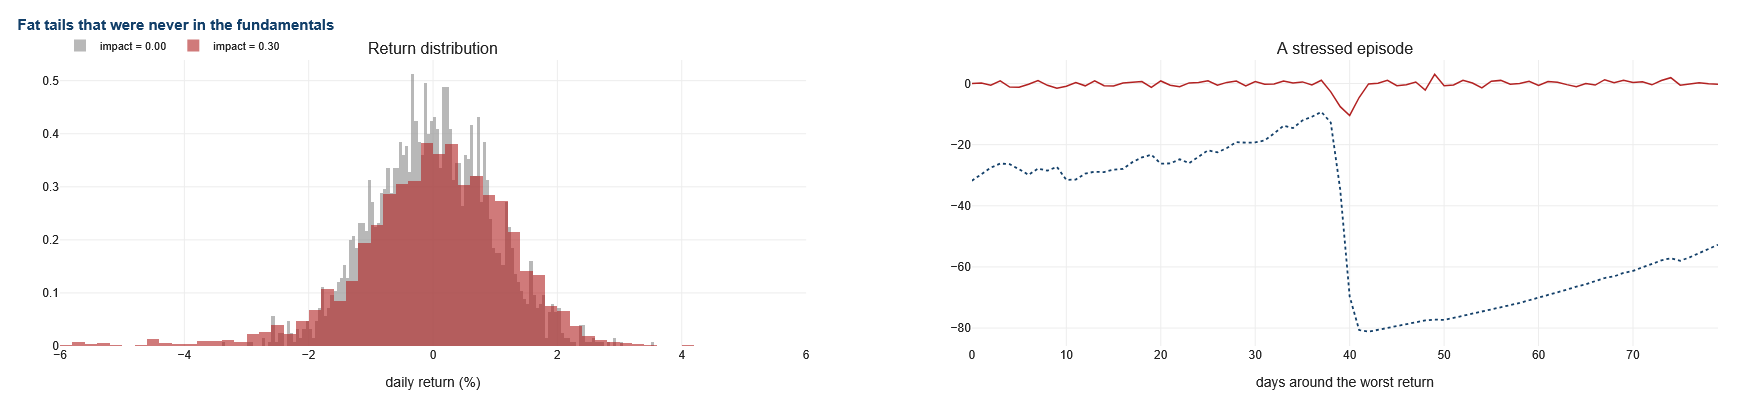

Excess kurtosis with no feedback:   +0.02  (Gaussian by construction)
Excess kurtosis with feedback:      +6.81
Worst day: -3.35%  ->  -10.44%


In [13]:
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=("Return distribution", "A stressed episode"))
for imp, colour in zip([0.0, 0.30], [a6.GREY, a6.RED]):
    d = runs[imp]
    fig.add_trace(go.Histogram(x=d["return"] * 100, nbinsx=140, opacity=0.6,
                               name=f"impact = {imp:.2f}", marker_color=colour,
                               histnorm="probability density"), row=1, col=1)

d = runs[0.30]
worst = int(d["return"].idxmin())
sl = slice(max(0, worst - 40), worst + 40)
fig.add_trace(go.Scatter(y=d["return"].iloc[sl].to_numpy() * 100, name="return",
                         line=dict(color=a6.RED, width=1.5), showlegend=False),
              row=1, col=2)
fig.add_trace(go.Scatter(y=d["leverage"].iloc[sl].to_numpy() * 100 - 100, name="leverage",
                         line=dict(color=a6.NAVY, width=1.8, dash="dot"), showlegend=False),
              row=1, col=2)

a6.style(fig, title="Fat tails that were never in the fundamentals", height=400)
fig.update_layout(barmode="overlay")
fig.update_xaxes(title="daily return (%)", range=[-6, 6], row=1, col=1)
fig.update_xaxes(title="days around the worst return", row=1, col=2)
fig.show()

base_k = runs[0.0]["return"].kurt()
fb_k = runs[0.30]["return"].kurt()
print(f"Excess kurtosis with no feedback:   {base_k:+.2f}  (Gaussian by construction)")
print(f"Excess kurtosis with feedback:      {fb_k:+.2f}")
print(f"Worst day: {runs[0.0]['return'].min()*100:.2f}%  ->  "
      f"{runs[0.30]['return'].min()*100:.2f}%")

**The fundamentals were Gaussian in every run.** The fat tails, the volatility
amplification and the worst day were all manufactured by a risk-management rule doing
exactly what it was designed to do.

This is not a criticism of volatility targeting specifically. Note the asymmetry: a *slow*
risk model is criticised for de-risking late (Notebook 06c, Model A's clustered breaches);
a *fast* one de-risks in unison with everyone else. **There is no setting of the dial that
removes the problem** — it is a property of many participants sharing a measurement rule.

### Why this matters more with AI

The [FSB (2024)](https://www.fsb.org/uploads/P14112024.pdf) names **increased market
correlations and herding** as one of four AI-related financial stability vulnerabilities.
The mechanism is the one you have just simulated. Correlated risk models already amplified
several episodes using OLS and a 250-day window; if institutions increasingly train on
similar data with similar architectures, the models get *better* and *more alike* at the
same time.

**Accuracy and homogeneity are not the same virtue.** That is the closing argument of
Lecture 6.

> **A caution on causal claims.** Position data for these strategies is not public. What the
> evidence establishes — including [BIS Bulletin 90](https://www.bis.org/publ/bisbull90.htm)
> on the August 2024 carry unwind — is that the mechanism exists and the flows point the
> same way. It does not establish that risk-based strategies *caused* any particular
> episode. Say the weaker thing accurately rather than the stronger thing loosely.

---
## Exercises

### Core

**C1.** Add a seventh asset that is highly correlated with JPM (say another large bank).
Recompute all three rules. Which changes most, and does the ERC portfolio recognise that the
two banks are near-substitutes?

**C2.** Run the ERC optimisation on the first half of the sample and hold those weights
through the second half. How far do the realised risk contributions drift from equality?
This is the estimation-risk question that the in-sample picture hides.

**C3.** Sweep the volatility target from 5% to 20% and plot realised volatility, Sharpe
ratio and turnover against the target. At what point does the leverage cap start binding,
and what does that do to the tracking of the target?

### Stretch

**S1.** Risk parity's long record leans on equities and bonds being negatively correlated.
Download a Treasury ETF (`IEF` or `TLT`) with `USE_LIVE`, build a two-asset risk parity
portfolio with equities, and plot the rolling 24-month correlation from 2019 to today.
Identify 2022 and explain what happened to the strategy's diversification.

**S2.** In the feedback simulation, make `impact` a function of the *level* of volatility so
that liquidity dries up in stress — a well-documented empirical regularity. Does the
distribution become more extreme, and is there an impact level at which the system stops
being stable?

**S3.** Replace the single volatility-targeting investor with $K$ investors who each use a
*different* volatility estimator (different EWMA decay, or a mix of EWMA and GARCH). Show
how the amplification depends on how similar their estimators are. This is a direct
simulation of the FSB's herding channel, and it is the strongest form of the argument in
Section 5 of this notebook.